# NB05 — ENIGMA Isolate Application

Apply the metal gene classifier to ENIGMA Genome Depot isolates. Rank by defense vs metabolism profile and identify top candidates.

In [1]:
import sys, os, re, warnings, requests, json, subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import fisher_exact, norm
from statsmodels.stats.multitest import fdrcorrection
warnings.filterwarnings("ignore")

try:
    spark
except NameError:
    sys.path.append('/opt/conda/lib/python3.13/site-packages')
    from berdl_notebook_utils.setup_spark_session import get_spark_session
    spark = get_spark_session()
spark.clearProgressHandlers()
import json as _json
class _SparkSafeEncoder(_json.JSONEncoder):
    def default(self, obj):
        try:
            return super().default(obj)
        except TypeError:
            return str(obj)
_json.JSONEncoder = _SparkSafeEncoder
_json._default_encoder = _SparkSafeEncoder()

from pyspark.sql import functions as F

NOTEBOOK_DIR = Path().resolve()
PROJECT_DIR  = NOTEBOOK_DIR.parent
DATA_DIR     = PROJECT_DIR / "data"
FIG_DIR      = PROJECT_DIR / "figures"
DATA_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

def is_valid_parquet(p):
    if not p.exists() or p.stat().st_size < 512:
        return False
    try:
        import pyarrow.parquet as pq; pq.read_schema(str(p)); return True
    except Exception:
        return False

DEFENSE_KOS   = ['K02585','K07633','K07634','K07635','K07636','K07637','K07638',
                  'K01551','K03455','K00537','K16551','K03756','K15523','K15524',
                  'K15525','K10783','K03078','K01533','K13579','K15724']
METABOLISM_KOS = ['K00114','K18155',
                   # pqqA-E (K11781-K11785) removed: pqqC absent throughout Thermoplasmatota,
                   # xoxF present in only 1/294; spurious annotation in non-methylotrophic archaea
                   'K02588','K02586','K02591','K22896','K22897','K22902','K16163',
                   'K01429','K01430','K01427','K00399','K14127','K05906']
HOMEOSTASIS_KOS = ['K06189','K03969','K03594','K04047','K09815','K09816','K09817',
                    'K07222','K15522','K18883','K23012']

print("Setup complete.")

Setup complete.


## Section 1 — Query ENIGMA Depot

Classify ENIGMA isolates using the same annotation vocabulary from NB01.

In [2]:
enigma_path = DATA_DIR / "enigma_isolate_classification.parquet"
if is_valid_parquet(enigma_path):
    enigma_df = pd.read_parquet(enigma_path)
    print(f"[cache] ENIGMA isolates: {len(enigma_df)}")
else:
    all_kos   = DEFENSE_KOS + METABOLISM_KOS + HOMEOSTASIS_KOS
    def_sql   = ", ".join(f"'{k}'" for k in DEFENSE_KOS)
    met_sql   = ", ".join(f"'{k}'" for k in METABOLISM_KOS)
    hom_sql   = ", ".join(f"'{k}'" for k in HOMEOSTASIS_KOS)
    all_sql   = ", ".join(f"'{k}'" for k in all_kos)

    enigma_df = spark.sql(f'''
        SELECT
            g.id AS genome_id,
            s.full_name AS organism_name,
            COUNT(DISTINCT CASE WHEN ko.kegg_id IN ({def_sql}) THEN ko.kegg_id END) AS n_defense,
            COUNT(DISTINCT CASE WHEN ko.kegg_id IN ({met_sql}) THEN ko.kegg_id END) AS n_metabolism,
            COUNT(DISTINCT CASE WHEN ko.kegg_id IN ({hom_sql}) THEN ko.kegg_id END) AS n_homeostasis,
            COUNT(DISTINCT CASE WHEN ko.kegg_id IN ({all_sql}) THEN ko.kegg_id END) AS n_metal_total
        FROM enigma_genome_depot_enigma.browser_genome g
        JOIN enigma_genome_depot_enigma.browser_strain s ON s.id = g.strain_id
        JOIN enigma_genome_depot_enigma.browser_gene ge ON ge.genome_id = g.id
        JOIN enigma_genome_depot_enigma.browser_protein_kegg_orthologs pko ON pko.protein_id = ge.protein_id
        JOIN enigma_genome_depot_enigma.browser_kegg_ortholog ko ON ko.id = pko.kegg_ortholog_id
        WHERE ko.kegg_id IN ({all_sql})
        GROUP BY g.id, s.full_name
    ''').toPandas()
    enigma_df.to_parquet(enigma_path, index=False)
    print(f"ENIGMA isolates classified: {len(enigma_df)}")

print(f"\nSummary statistics:")
print(enigma_df[['n_defense', 'n_metabolism', 'n_homeostasis', 'n_metal_total']].describe())

[cache] ENIGMA isolates: 2879

Summary statistics:
         n_defense  n_metabolism  n_homeostasis  n_metal_total
count  2879.000000   2879.000000    2879.000000    2879.000000
mean      5.733935      1.963182       4.939562      12.636679
std       1.548632      1.250170       1.993865       3.873789
min       0.000000      0.000000       0.000000       1.000000
25%       5.000000      1.000000       3.000000      10.000000
50%       6.000000      2.000000       5.000000      13.000000
75%       7.000000      3.000000       7.000000      16.000000
max      10.000000      6.000000       8.000000      21.000000


## Section 2 — Rank Candidates

Compute z-scores and composite ranking to identify top metabolic specialists.

In [3]:
enigma_df['z_defense'] = (enigma_df['n_defense'] - enigma_df['n_defense'].mean()) / enigma_df['n_defense'].std()
enigma_df['z_metabolism'] = (enigma_df['n_metabolism'] - enigma_df['n_metabolism'].mean()) / enigma_df['n_metabolism'].std()
enigma_df['z_homeostasis'] = (enigma_df['n_homeostasis'] - enigma_df['n_homeostasis'].mean()) / enigma_df['n_homeostasis'].std()

enigma_df['z_defense'] = enigma_df['z_defense'].fillna(0)
enigma_df['z_metabolism'] = enigma_df['z_metabolism'].fillna(0)
enigma_df['z_homeostasis'] = enigma_df['z_homeostasis'].fillna(0)

enigma_df['composite_score'] = enigma_df['z_metabolism'] * 40 + enigma_df['z_homeostasis'] * 10 - enigma_df['z_defense'] * 5

enigma_ranked = enigma_df.sort_values('n_metabolism', ascending=False).reset_index(drop=True)
enigma_ranked['rank'] = range(1, len(enigma_ranked) + 1)

enigma_ranked[['genome_id', 'organism_name', 'n_defense', 'n_metabolism', 'n_homeostasis',
               'z_defense', 'z_metabolism', 'z_homeostasis', 'composite_score', 'rank']
              ].to_csv(DATA_DIR / "enigma_isolate_classification.csv", index=False)

print("Top 20 ENIGMA isolates by metabolism gene count:")
print(enigma_ranked.head(20)[['genome_id', 'organism_name', 'n_defense', 'n_metabolism', 'n_homeostasis', 'composite_score']])

Top 20 ENIGMA isolates by metabolism gene count:
    genome_id                                      organism_name  n_defense  \
0        1224                        Sinorhizobium meliloti 1021          8   
1        1279               Environmental isolate GW821-FHT04F04          7   
2         756  Environmental isolate GW821-FHT02A12 Unconfirm...          7   
3         271                     Environmental isolate FW305-24          8   
4        3648               Environmental isolate GW822-FHT05C06          8   
5        4135                            Paraburkholderia sabiae          7   
6         805  Environmental isolate GW821-FHT03D11 Unconfirm...          7   
7        3518                  Environmental isolate EB271-A4-7B          8   
8           5                      Azospirillum brasilense Sp245          7   
9        3388                     Environmental isolate FW305-F6          7   
10        465              Environmental isolate FW306-2-2C-D06C          6   
11 

## Section 3 — Scatter: Defense vs Metabolism

Visualize ENIGMA isolates with top candidates labeled.

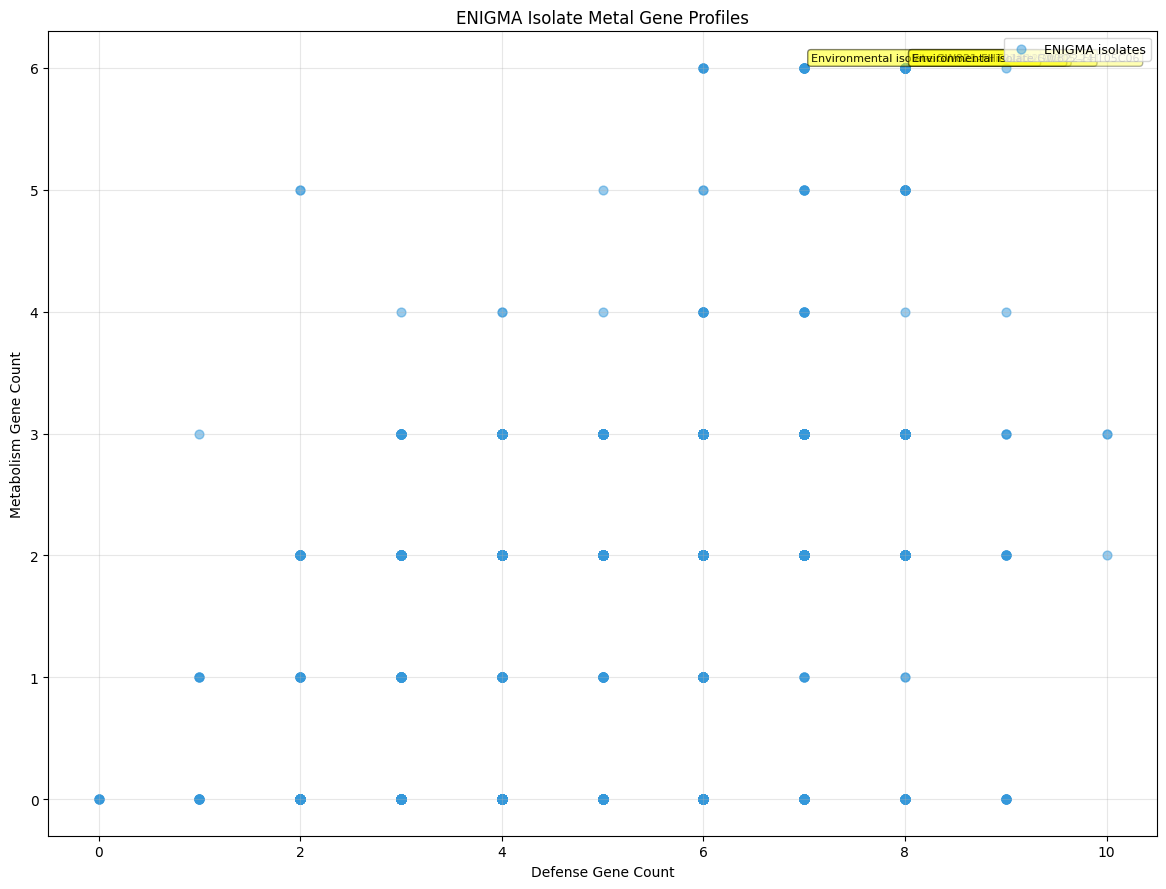

Figure saved: nb05_enigma_scatter.png


In [4]:
fig, ax = plt.subplots(figsize=(12, 9))

ax.scatter(enigma_df['n_defense'], enigma_df['n_metabolism'],
           alpha=0.5, s=40, color='#3498db', label='ENIGMA isolates')

# Label top 5 by metabolism
top5 = enigma_ranked.head(5)
for _, row in top5.iterrows():
    ax.annotate(str(row['organism_name'])[:40],
               xy=(row['n_defense'], row['n_metabolism']),
               xytext=(5, 5), textcoords='offset points',
               fontsize=8, alpha=0.7,
               bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))

ax.set_xlabel('Defense Gene Count')
ax.set_ylabel('Metabolism Gene Count')
ax.set_title('ENIGMA Isolate Metal Gene Profiles')
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "nb05_enigma_scatter.png", dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved: nb05_enigma_scatter.png")